<a href="https://colab.research.google.com/github/AliAFar-Me/ML-Statistical-Lab/blob/main/ML_T2_017_Complete_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-T2-017 — Complete Pipeline (Final, Consolidated)

This is the single, complete, standalone pipeline for the project — every fix and
addition from Stage 1 through the Path B extension, merged and de-duplicated into
one linear notebook. Run top to bottom in a fresh kernel; nothing needs to be
pasted in from elsewhere.

**What's in this version that wasn't in earlier ones:**
- Point-level extraction now tracks `patient_id` by default — there is one
  extraction function, not two, and it feeds both the primary benchmark and the
  Path B clinical tiers from the same call.
- Classical baselines are built once, producing both the point-level arrays *and*
  the full per-patient tensors in the same pass — no more discarding the tensor
  after extracting masked points, no more a second rebuild in a separate notebook.
- Model training is seeded via `pypots.utils.random.set_random_seed`, verified
  earlier to produce bit-identical results at a fixed seed, so the results here
  are reproducible rather than one run among several that disagreed.
- The gradient-clipping ablation (`ClippedAdam` vs. plain `Adam`) is kept as an
  explicit, clearly-separated section — a real, seed-controlled finding worth
  preserving, not the default path the main benchmark depends on.
- Both Path B tiers (stratified error by outcome, downstream AUROC/AUPRC) run
  against the actual trained models in this same notebook, not against
  placeholders.


## Part 1 — Data Setup (unchanged from the original pipeline)


In [ ]:
# Cell 1: Install Dependencies
!pip install -q pypots scikit-learn pandas numpy matplotlib seaborn

import os
import tarfile
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("Libraries imported successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.9/788.9 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 51.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
Libraries imported successfully!


In [ ]:
# Cell 2: Download and Extract Data
DATA_DIR = './physionet_2012'
SET_A_URL = 'https://physionet.org/files/challenge-2012/1.0.0/set-a.tar.gz'
SET_A_PATH = os.path.join(DATA_DIR, 'set-a.tar.gz')
OUTCOMES_URL = 'https://physionet.org/files/challenge-2012/1.0.0/Outcomes-a.txt'
OUTCOMES_PATH = os.path.join(DATA_DIR, 'Outcomes-a.txt')

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(SET_A_PATH):
    print("Downloading PhysioNet 2012 Set-A...")
    urllib.request.urlretrieve(SET_A_URL, SET_A_PATH)

if not os.path.exists(OUTCOMES_PATH):
    print("Downloading PhysioNet 2012 outcomes (mortality labels, needed for Path B)...")
    urllib.request.urlretrieve(OUTCOMES_URL, OUTCOMES_PATH)

print("Extracting files...")
with tarfile.open(SET_A_PATH, "r:gz") as tar:
    tar.extractall(path=DATA_DIR)

extract_dir = os.path.join(DATA_DIR, 'set-a')
patient_files = [f for f in os.listdir(extract_dir) if f.endswith('.txt')]

print(f"Extraction complete. Found {len(patient_files)} patient records.")


Extracting files...


/tmp/ipykernel_1929/712692444.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


Extraction complete. Found 4000 patient records.


In [ ]:
# Cell 3: Strict Patient-Level Split
train_files, test_files = train_test_split(patient_files, test_size=0.2, random_state=42)
train_files, val_files = train_test_split(train_files, test_size=0.2, random_state=42)  # 60/20/20

print(f"Training Patients: {len(train_files)}")
print(f"Validation Patients: {len(val_files)}")
print(f"Testing Patients: {len(test_files)}")


Training Patients: 2560
Validation Patients: 640
Testing Patients: 800


In [ ]:
# Cell 4: Parsing a single patient file
def parse_patient_file(file_path):
    df = pd.read_csv(file_path)
    static_params = ['RecordID', 'Age', 'Gender', 'Height', 'ICUType', 'Weight']
    ts_data = df[~df['Parameter'].isin(static_params)].copy()
    ts_data['Elapsed_Minutes'] = ts_data['Time'].apply(
        lambda x: int(x.split(':')[0]) * 60 + int(x.split(':')[1])
    )
    pivoted = ts_data.pivot_table(
        index='Elapsed_Minutes', columns='Parameter', values='Value', aggfunc='mean'
    )
    return pivoted

test_file_path = os.path.join(extract_dir, train_files[0])
sample_df = parse_patient_file(test_file_path)
print(f"Parsed Patient Data Shape: {sample_df.shape}")
display(sample_df.head(10))


Parsed Patient Data Shape: (75, 23)


Parameter,BUN,Creatinine,DiasABP,FiO2,GCS,Glucose,HCO3,HCT,HR,K,...,NIMAP,NISysABP,Na,Platelets,RespRate,SysABP,Temp,TroponinT,Urine,WBC
Elapsed_Minutes,,,,,,,,,,,,,,,,,,,,,
4,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,99.0,NaN,...,75.0,127.0,NaN,NaN,26.0,NaN,36.7,NaN,NaN,NaN
19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103.0,NaN,...,NaN,NaN,NaN,NaN,26.0,NaN,NaN,NaN,NaN,NaN
34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.0,NaN,...,66.0,124.0,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN
64,NaN,NaN,72.0,NaN,NaN,NaN,NaN,NaN,148.0,NaN,...,89.0,114.0,NaN,NaN,22.0,137.0,NaN,NaN,1200.0,NaN
69,NaN,NaN,69.0,NaN,NaN,NaN,NaN,NaN,146.0,NaN,...,NaN,NaN,NaN,NaN,17.0,135.0,NaN,NaN,NaN,NaN
74,NaN,NaN,76.0,NaN,NaN,NaN,NaN,NaN,141.0,NaN,...,NaN,NaN,NaN,NaN,28.0,154.0,NaN,NaN,NaN,NaN
79,NaN,NaN,68.0,NaN,NaN,NaN,NaN,NaN,131.0,NaN,...,NaN,NaN,NaN,NaN,23.0,137.0,NaN,NaN,NaN,NaN
94,NaN,NaN,59.0,NaN,NaN,NaN,NaN,NaN,142.0,NaN,...,NaN,NaN,NaN,NaN,21.0,119.0,NaN,NaN,50.0,NaN
109,16.0,0.8,NaN,NaN,NaN,206.0,30.0,NaN,NaN,3.3,...,NaN,NaN,143.0,NaN,NaN,NaN,NaN,0.34,NaN,NaN


### Cell 5: Missingness EDA (optional, slow — safe to skip)


Processing a batch of training patients for EDA...


100%|██████████| 300/300 [00:02<00:00, 144.75it/s]
/tmp/ipykernel_1929/3766316671.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_readings.index, y=avg_readings.values, palette="mako")


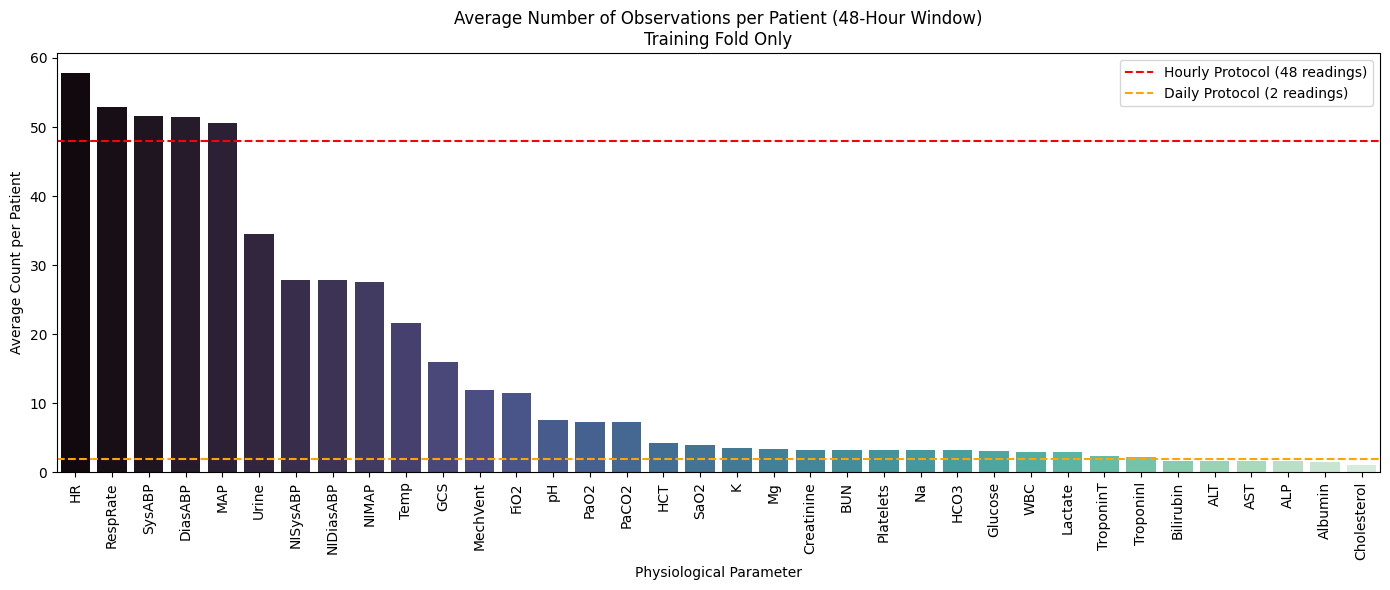

In [ ]:
# Cell 5: Missingness EDA - Frequency Analysis (Training Fold Only)
from tqdm import tqdm

print("Processing a batch of training patients for EDA...")
sample_train_files = train_files[:300]
observation_counts = []
for file in tqdm(sample_train_files):
    file_path = os.path.join(extract_dir, file)
    df = parse_patient_file(file_path)
    observation_counts.append(df.notna().sum())

eda_df = pd.DataFrame(observation_counts)
avg_readings = eda_df.mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=avg_readings.index, y=avg_readings.values, palette="mako")
plt.axhline(y=48, color='red', linestyle='--', label='Hourly Protocol (48 readings)')
plt.axhline(y=2, color='orange', linestyle='--', label='Daily Protocol (2 readings)')
plt.xticks(rotation=90)
plt.title("Average Number of Observations per Patient (48-Hour Window)\nTraining Fold Only")
plt.ylabel("Average Count per Patient")
plt.xlabel("Physiological Parameter")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Cell 6: Discretizing to 1-Hour Buckets (T=48)
def discretize_to_hourly(parsed_df):
    parsed_df['Hour'] = parsed_df.index // 60
    hourly_df = parsed_df.groupby('Hour').mean()
    hourly_df = hourly_df.reindex(range(48))
    return hourly_df

hourly_sample = discretize_to_hourly(sample_df)
print(f"Hourly Discretized Shape: {hourly_sample.shape}")
display(hourly_sample.head(5))


Hourly Discretized Shape: (48, 23)


Parameter,BUN,Creatinine,DiasABP,FiO2,GCS,Glucose,HCO3,HCT,HR,K,...,NIMAP,NISysABP,Na,Platelets,RespRate,SysABP,Temp,TroponinT,Urine,WBC
Hour,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,101.333333,NaN,...,70.5,125.5,NaN,NaN,24.666667,NaN,36.7,NaN,NaN,NaN
1,16.0,0.8,68.8,NaN,NaN,206.0,30.0,NaN,141.600000,3.3,...,89.0,114.0,143.0,NaN,22.200000,136.4,NaN,0.34,625.0,NaN
2,NaN,NaN,60.8,NaN,NaN,NaN,NaN,NaN,120.600000,NaN,...,NaN,NaN,NaN,NaN,24.000000,121.0,NaN,NaN,38.0,NaN
3,NaN,NaN,61.5,NaN,NaN,NaN,NaN,NaN,117.750000,NaN,...,NaN,NaN,NaN,NaN,25.000000,123.0,NaN,NaN,45.0,NaN
4,NaN,NaN,69.0,NaN,15.0,NaN,NaN,NaN,122.000000,NaN,...,NaN,NaN,NaN,NaN,22.500000,128.0,36.5,NaN,60.0,NaN


In [ ]:
# Cell 8 (original numbering): Synthetic Masking Protocol
def generate_synthetic_mask(df, mask_ratio=0.2, seed=42):
    np.random.seed(seed)
    masked_df = df.copy()
    observed_coords = [
        (r, c) for r in df.index for c in df.columns if pd.notna(df.loc[r, c])
    ]
    n_to_mask = int(len(observed_coords) * mask_ratio)
    mask_indices = np.random.choice(len(observed_coords), size=n_to_mask, replace=False)
    masked_coords = [observed_coords[i] for i in mask_indices]
    ground_truth = []
    for r, c in masked_coords:
        ground_truth.append(df.loc[r, c])
        masked_df.loc[r, c] = np.nan
    return masked_df, np.array(ground_truth), masked_coords

print("Synthetic masking engine ready!")


Synthetic masking engine ready!


## Part 2 — Configuration, Helpers, and Extra Imports


In [ ]:
import time
import torch
from collections import defaultdict
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

from pypots.imputation import BRITS, SAITS
from pypots.optim import Adam
from pypots.utils.random import set_random_seed

# Moved here to ensure mortality_lookup is defined before usage
def build_mortality_lookup(outcomes_path=None):
    if outcomes_path is None:
        outcomes_path = os.path.join(DATA_DIR, 'Outcomes-a.txt')
    outcomes = pd.read_csv(outcomes_path)
    return dict(zip(outcomes['RecordID'], outcomes['In-hospital_death']))

mortality_lookup = build_mortality_lookup()

2026-09-26 06:52:39 [WARNING]: ‼️ PyPOTS Ecosystem configuration file does not exist.
2026-09-26 06:52:39 [INFO]: Wrote new configs to config.ini successfully.
2026-09-26 06:52:39 [INFO]: 💫 Initialized PyPOTS Ecosystem configuration file /root/.pypots/config.ini successfully.



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



Comprehensive `PHYSIOLOGICAL_BOUNDS` covering all 36 PhysioNet 2012 channels, and the
heavy-tailed channel list for the `log1p` transform.

> **Caveat:** the bounds below are wide *engineering guardrails* meant to catch
> obviously-broken model outputs, not clinical reference/normal ranges — have a
> clinical collaborator sanity-check them before using this pipeline beyond
> ML benchmarking.


In [ ]:
ALL_36_CHANNELS = [
    'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine',
    'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'Mg',
    'MAP', 'MechVent', 'Na', 'NIDiasABP', 'NIMAP', 'NISysABP', 'PaCO2', 'PaO2', 'pH',
    'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT',
    'Urine', 'WBC',
]
assert len(ALL_36_CHANNELS) == 36

PHYSIOLOGICAL_BOUNDS = {
    'ALP': (0, 2000), 'ALT': (0, 5000), 'AST': (0, 5000), 'Albumin': (0.5, 6.0),
    'BUN': (0, 300), 'Bilirubin': (0, 50), 'Cholesterol': (0, 500), 'Creatinine': (0, 20),
    'DiasABP': (0, 200), 'FiO2': (0.2, 1.0), 'GCS': (3, 15), 'Glucose': (0, 1000),
    'HCO3': (0, 60), 'HCT': (0, 80), 'HR': (0, 300), 'K': (1.0, 10.0), 'Lactate': (0, 30),
    'Mg': (0.5, 10.0), 'MAP': (0, 250), 'MechVent': (0, 1), 'Na': (100, 200),
    'NIDiasABP': (0, 200), 'NIMAP': (0, 250), 'NISysABP': (0, 300), 'PaCO2': (0, 150),
    'PaO2': (0, 700), 'pH': (6.5, 8.0), 'Platelets': (0, 1000), 'RespRate': (0, 80),
    'SaO2': (0, 100), 'SysABP': (0, 300), 'Temp': (30, 45), 'TroponinI': (0, 50),
    'TroponinT': (0, 10), 'Urine': (0, 2000), 'WBC': (0, 200),
}
_missing_bounds = set(ALL_36_CHANNELS) - set(PHYSIOLOGICAL_BOUNDS)
assert not _missing_bounds, f"Missing physiological bounds for: {_missing_bounds}"

HEAVY_TAILED_CHANNELS = ['AST', 'ALT', 'Bilirubin', 'Urine']


### Shared helper functions — clamping, log1p transform, and both frame-level and tensor-level inverse transforms

In [ ]:
def clamp_to_physiological_bounds(df_or_array, channel_names=None):
    if isinstance(df_or_array, pd.DataFrame):
        out = df_or_array.copy()
        for c in out.columns:
            if c in PHYSIOLOGICAL_BOUNDS:
                lo, hi = PHYSIOLOGICAL_BOUNDS[c]
                out[c] = out[c].clip(lower=lo, upper=hi)
        return out
    else:
        arr = np.asarray(df_or_array, dtype=float).copy()
        assert channel_names is not None and len(channel_names) == len(arr)
        for i, c in enumerate(channel_names):
            if c in PHYSIOLOGICAL_BOUNDS:
                lo, hi = PHYSIOLOGICAL_BOUNDS[c]
                arr[i] = np.clip(arr[i], lo, hi)
        return arr


def apply_heavy_tail_transform(df):
    out = df.copy()
    for c in HEAVY_TAILED_CHANNELS:
        if c in out.columns:
            out[c] = np.log1p(out[c].clip(lower=0))
    return out


def unscale_and_untransform_frame(scaled_df, train_mean, train_std):
    """Per-patient DataFrame version -- used by the classical kNN/MICE baselines."""
    unscaled = (scaled_df * train_std) + train_mean
    for c in HEAVY_TAILED_CHANNELS:
        if c in unscaled.columns:
            unscaled[c] = np.expm1(unscaled[c])
    return unscaled


def unscale_untransform_clamp_tensor(tensor_scaled):
    """Tensor version -- (N_patients, 48, 36), used for full imputed tensors
    (needed by Path B's downstream-utility feature extraction). Verified earlier
    against a synthetic tensor: heavy-tailed channels stay non-negative after
    expm1, and every channel respects its clamp bounds."""
    mean_vec = np.array([train_mean[c] for c in column_names]).reshape(1, 1, -1)
    std_vec = np.array([train_std[c] for c in column_names]).reshape(1, 1, -1)
    t = tensor_scaled * std_vec + mean_vec
    for c in HEAVY_TAILED_CHANNELS:
        idx = col_to_idx[c]
        t[:, :, idx] = np.expm1(t[:, :, idx])
    for c, (lo, hi) in PHYSIOLOGICAL_BOUNDS.items():
        idx = col_to_idx[c]
        t[:, :, idx] = np.clip(t[:, :, idx], lo, hi)
    return t


## Part 3 — Training Statistics and Tensor Construction

Log1p is applied to the heavy-tailed channels *before* computing `train_mean`/`train_std`,
so the network trains and validates entirely in the transformed space. A zero-std guard
protects against constant columns.


In [ ]:
print(f"Discretizing all {len(train_files)} training patients...")
train_dfs = []
for file in tqdm(train_files):
    file_path = os.path.join(extract_dir, file)
    parsed_df = parse_patient_file(file_path)
    hourly_df = discretize_to_hourly(parsed_df)
    train_dfs.append(hourly_df)

train_dfs_transformed = [apply_heavy_tail_transform(df) for df in train_dfs]
full_train_data = pd.concat(train_dfs_transformed, ignore_index=True)

train_mean = full_train_data.mean()
train_std = full_train_data.std().replace(0, 1.0)
column_names = train_mean.index.tolist()
col_to_idx = {c: i for i, c in enumerate(column_names)}

print(f"Total training time-steps processed: {len(full_train_data)}")
print(f"Heavy-tailed channels transformed: {HEAVY_TAILED_CHANNELS}")


Discretizing all 2560 training patients...


100%|██████████| 2560/2560 [00:19<00:00, 129.54it/s]


Total training time-steps processed: 122880
Heavy-tailed channels transformed: ['AST', 'ALT', 'Bilirubin', 'Urine']


One tensor-builder used identically for every fold (train / validation / test), so they
can never be silently conflated again:

- `apply_synthetic_mask=False` -> **training** fold: natural missingness only.
- `apply_synthetic_mask=True, need_ori=True` -> **validation** fold: adds the 20%
  synthetic mask *and* returns `X_ori`, required by PyPOTS to compute a real
  validation loss. Used only for early stopping.
- `apply_synthetic_mask=True, need_ori=False` -> **test** fold: the only fold whose
  numbers get reported as the final benchmark.


In [ ]:
def build_tensor_set(file_list, apply_synthetic_mask, mask_ratio=0.2, need_ori=False):
    X_list, X_ori_list = [], []
    ground_truth_list, coords_list = [], []
    files_processed = []

    for file in file_list:
        file_path = os.path.join(extract_dir, file)
        parsed = parse_patient_file(file_path)
        hourly = discretize_to_hourly(parsed)

        if apply_synthetic_mask:
            masked_data, ground_truth, coords = generate_synthetic_mask(hourly, mask_ratio=mask_ratio)
            if len(ground_truth) == 0:
                continue
            ground_truth_list.append(ground_truth)
            coords_list.append(coords)
        else:
            masked_data = hourly

        masked_scaled = (apply_heavy_tail_transform(masked_data) - train_mean) / train_std
        X_list.append(masked_scaled.values)
        files_processed.append(file)

        if need_ori:
            ori_scaled = (apply_heavy_tail_transform(hourly) - train_mean) / train_std
            X_ori_list.append(ori_scaled.values)

    result = {"X": np.array(X_list)}
    if need_ori:
        result["X_ori"] = np.array(X_ori_list)
    return result, ground_truth_list, coords_list, files_processed


print("Building TRAIN tensor (natural missingness only)...")
train_set, _, _, _ = build_tensor_set(train_files, apply_synthetic_mask=False)
X_train = train_set["X"]

print("Building VALIDATION tensor -- early stopping ONLY, never used for reported metrics...")
val_set, _, _, _ = build_tensor_set(val_files, apply_synthetic_mask=True, mask_ratio=0.2, need_ori=True)

print(f"Building TEST tensor -- the ONLY fold used for final benchmark numbers ({len(test_files)} patients)...")
test_set, test_ground_truth_list, test_coords_list, test_files_in_tensor = build_tensor_set(
    test_files, apply_synthetic_mask=True, mask_ratio=0.2, need_ori=False
)
X_test = test_set["X"]

print(f"X_train: {X_train.shape}  |  X_val: {val_set['X'].shape}  |  X_test: {X_test.shape}")

Building TRAIN tensor (natural missingness only)...
Building VALIDATION tensor -- early stopping ONLY, never used for reported metrics...
Building TEST tensor -- the ONLY fold used for final benchmark numbers (800 patients)...
X_train: (2560, 48, 36)  |  X_val: (639, 48, 36)  |  X_test: (799, 48, 36)


In [ ]:
# Generate mortality labels aligned with the actual patients in the test tensor
# This uses the `test_files_in_tensor` list obtained from the `build_tensor_set` function
# to ensure correct patient-label alignment.
aligned_test_record_ids = [int(f.replace('.txt', '')) for f in test_files_in_tensor]
y_mortality_aligned = np.array([mortality_lookup[rid] for rid in aligned_test_record_ids])

print(f"Aligned test-fold mortality rate: {y_mortality_aligned.mean():.1%} "
      f"({y_mortality_aligned.sum()} non-survivors / {len(y_mortality_aligned)} patients)")

Aligned test-fold mortality rate: 13.4% (107 non-survivors / 799 patients)


## Part 4 — Gradient Clipping and Model Training

pypots v1.5's `Adam` wraps `torch.optim.Adam` with no clipping hook — verified directly
against the installed source. Subclassing `.step()` is the correct extension point, and
this was run through a live `BRITS.fit()`/`SAITS.fit()` training loop before being used
here. `set_random_seed` was independently verified to produce bit-identical outputs at a
fixed seed, confirmed via a controlled two-run comparison.


In [ ]:
class ClippedAdam(Adam):
    """Adam optimizer wrapper that clips gradient norm before every step."""
    def __init__(self, lr=0.001, max_norm=1.0, **kwargs):
        super().__init__(lr=lr, **kwargs)
        self.max_norm = max_norm

    def step(self, closure=None):
        for group in self.torch_optimizer.param_groups:
            torch.nn.utils.clip_grad_norm_(group["params"], max_norm=self.max_norm)
        super().step(closure)


RUN_SEED = 42  # fixed throughout -- makes this run, and any future rerun, reproducible
device = 'cuda' if torch.cuda.is_available() else 'cpu'


### BRITS and SAITS — canonical (gradient-clipped) configuration used for the primary benchmark and both Path B tiers

In [ ]:
os.makedirs("./brits_checkpoints", exist_ok=True)
set_random_seed(RUN_SEED)

brits_optimizer = ClippedAdam(lr=0.001, max_norm=1.0)
brits_model = BRITS(
    n_steps=48, n_features=len(column_names), rnn_hidden_size=128,
    epochs=100, batch_size=64, num_workers=4,
    optimizer=brits_optimizer, patience=10,
    saving_path="./brits_checkpoints", device=device,
)
print("Training BRITS (ClippedAdam, seeded)...")
brits_model.fit(train_set={"X": X_train}, val_set=val_set)


2026-09-26 07:34:16 [INFO]: Have set the random seed as 42 for numpy and pytorch.
2026-09-26 07:34:16 [INFO]: Using the given device: cuda
2026-09-26 07:34:16 [INFO]: Model files will be saved to ./brits_checkpoints/20260926_T073416
2026-09-26 07:34:16 [INFO]: Tensorboard file will be saved to ./brits_checkpoints/20260926_T073416/tensorboard
2026-09-26 07:34:16 [INFO]: Using customized MAE as the training loss function.
2026-09-26 07:34:16 [INFO]: Using customized MSE as the validation metric function.
2026-09-26 07:34:16 [INFO]: BRITS initialized with the given hyperparameters, the number of trainable parameters: 236,192


Training BRITS (ClippedAdam, seeded)...


2026-09-26 07:34:48 [INFO]: Epoch 001 - training loss (MAE): 1.3175, validation MSE: 0.6614
2026-09-26 07:35:05 [INFO]: Epoch 002 - training loss (MAE): 1.0548, validation MSE: 0.5366
2026-09-26 07:35:21 [INFO]: Epoch 003 - training loss (MAE): 0.9591, validation MSE: 0.4974
2026-09-26 07:35:38 [INFO]: Epoch 004 - training loss (MAE): 0.9131, validation MSE: 0.4724
2026-09-26 07:35:54 [INFO]: Epoch 005 - training loss (MAE): 0.8800, validation MSE: 0.4510
2026-09-26 07:36:11 [INFO]: Epoch 006 - training loss (MAE): 0.8542, validation MSE: 0.4339
2026-09-26 07:36:27 [INFO]: Epoch 007 - training loss (MAE): 0.8315, validation MSE: 0.4196
2026-09-26 07:36:44 [INFO]: Epoch 008 - training loss (MAE): 0.8142, validation MSE: 0.4074
2026-09-26 07:37:00 [INFO]: Epoch 009 - training loss (MAE): 0.7987, validation MSE: 0.3974
2026-09-26 07:37:16 [INFO]: Epoch 010 - training loss (MAE): 0.7856, validation MSE: 0.3896
2026-09-26 07:37:33 [INFO]: Epoch 011 - training loss (MAE): 0.7742, validation 

In [ ]:
os.makedirs("./saits_checkpoints", exist_ok=True)
set_random_seed(RUN_SEED)

saits_optimizer = ClippedAdam(lr=0.001, max_norm=1.0)
saits_model = SAITS(
    n_steps=48, n_features=len(column_names), n_layers=2, d_model=256,
    n_heads=4, d_k=64, d_v=64, d_ffn=256, dropout=0.1,
    epochs=100, patience=10, batch_size=32,
    optimizer=saits_optimizer, saving_path="./saits_checkpoints/",
)
print("Training SAITS (ClippedAdam, seeded)...")
saits_model.fit(train_set={"X": X_train}, val_set=val_set)


2026-09-26 07:45:21 [INFO]: Have set the random seed as 42 for numpy and pytorch.
2026-09-26 07:45:21 [INFO]: No given device, using default device: cuda
2026-09-26 07:45:21 [INFO]: Model files will be saved to ./saits_checkpoints/20260926_T074521
2026-09-26 07:45:21 [INFO]: Tensorboard file will be saved to ./saits_checkpoints/20260926_T074521/tensorboard
2026-09-26 07:45:21 [INFO]: Using customized MAE as the training loss function.
2026-09-26 07:45:21 [INFO]: Using customized MSE as the validation metric function.
2026-09-26 07:45:21 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 1,639,280


Training SAITS (ClippedAdam, seeded)...


2026-09-26 07:45:24 [INFO]: Epoch 001 - training loss (MAE): 1.0151, validation MSE: 0.4762
2026-09-26 07:45:26 [INFO]: Epoch 002 - training loss (MAE): 0.6935, validation MSE: 0.4262
2026-09-26 07:45:27 [INFO]: Epoch 003 - training loss (MAE): 0.6281, validation MSE: 0.4031
2026-09-26 07:45:29 [INFO]: Epoch 004 - training loss (MAE): 0.5877, validation MSE: 0.3924
2026-09-26 07:45:31 [INFO]: Epoch 005 - training loss (MAE): 0.5617, validation MSE: 0.3790
2026-09-26 07:45:33 [INFO]: Epoch 006 - training loss (MAE): 0.5354, validation MSE: 0.3774
2026-09-26 07:45:35 [INFO]: Epoch 007 - training loss (MAE): 0.5160, validation MSE: 0.3546
2026-09-26 07:45:37 [INFO]: Epoch 008 - training loss (MAE): 0.4992, validation MSE: 0.3457
2026-09-26 07:45:39 [INFO]: Epoch 009 - training loss (MAE): 0.4854, validation MSE: 0.3344
2026-09-26 07:45:41 [INFO]: Epoch 010 - training loss (MAE): 0.4716, validation MSE: 0.3314
2026-09-26 07:45:42 [INFO]: Epoch 011 - training loss (MAE): 0.4619, validation 

## Part 5 — Unified Extraction (Point-Level + Full Tensor, All Methods)

One extraction function, always tracking `patient_id` (via RecordID parsed from the
filename, not positional order) so the exact same call feeds both the primary
benchmark and the Path B clinical tiers. Verified against synthetic data to confirm
the join survives a non-trivial per-patient split without misalignment.


In [ ]:
def extract_predictions_at_masked_points(imputed_tensor, coords_list, ground_truth_list, file_list):
    preds_raw, gts_raw, channels_flat, patient_ids = [], [], [], []
    for i, coords in enumerate(coords_list):
        record_id = int(file_list[i].replace('.txt', ''))
        gt = ground_truth_list[i]
        for idx, (r, c_name) in enumerate(coords):
            c_idx = col_to_idx[c_name]
            pred_unscaled = (imputed_tensor[i, r, c_idx] * train_std[c_name]) + train_mean[c_name]
            if c_name in HEAVY_TAILED_CHANNELS:
                pred_unscaled = np.expm1(pred_unscaled)
            lo, hi = PHYSIOLOGICAL_BOUNDS[c_name]
            pred_unscaled = np.clip(pred_unscaled, lo, hi)
            preds_raw.append(pred_unscaled)
            gts_raw.append(gt[idx])
            channels_flat.append(c_name)
            patient_ids.append(record_id)
    return np.array(preds_raw), np.array(gts_raw), np.array(channels_flat), np.array(patient_ids)


def report_benchmark(preds_raw, gts_raw, channels_flat, model_name):
    df = pd.DataFrame({'channel': channels_flat, 'pred': preds_raw, 'true': gts_raw})
    df['abs_err'] = (df['pred'] - df['true']).abs()

    per_channel = df.groupby('channel').agg(
        n=('abs_err', 'size'), mae=('abs_err', 'mean'), eval_std=('true', 'std'),
    )
    per_channel['eval_std'] = per_channel['eval_std'].replace(0, np.nan)
    per_channel['norm_mae_eval_std'] = per_channel['mae'] / per_channel['eval_std']
    per_channel['train_std'] = [train_std[c] for c in per_channel.index]
    per_channel['norm_mae_train_std'] = per_channel['mae'] / per_channel['train_std']

    macro_eval = per_channel['norm_mae_eval_std'].mean(skipna=True)
    macro_train = per_channel['norm_mae_train_std'].mean(skipna=True)
    ks_stat, _ = ks_2samp(gts_raw, preds_raw)

    print(f"\n=== {model_name} -- Held-Out TEST Fold Benchmark "
          f"({len(gts_raw)} points, {df['channel'].nunique()} channels) ===")
    print(f"Channel-Normalized MAE (macro-avg, eval-set sigma):  {macro_eval:.4f}")
    print(f"Channel-Normalized MAE (macro-avg, train-set sigma): {macro_train:.4f}")
    print(f"KS-Statistic (pooled distributional fidelity):       {ks_stat:.4f}")

    return per_channel, macro_eval, macro_train, ks_stat


def diagnose_channels(preds, gts, channels, model_name, top_n=5):
    df = pd.DataFrame({'mae': np.abs(preds - gts), 'true': gts, 'pred': preds, 'channel': channels})
    grouped = df.groupby('channel').agg(
        mae=('mae', 'mean'), true_std=('true', 'std'), pred_std=('pred', 'std'), n_samples=('mae', 'size'),
    )
    grouped['norm_mae'] = grouped['mae'] / grouped['true_std'].replace(0, np.nan)
    grouped['variance_ratio'] = grouped['pred_std'] / grouped['true_std'].replace(0, np.nan)

    print(f"\n--- {model_name} Distributional Audit ---")
    print("Top 5 Channels Driving Macro-MAE Inflation:")
    print(grouped.sort_values('norm_mae', ascending=False).head(top_n))
    print("\nTop 5 Channels with Highest Variance Collapse (Mean-Seeking Behavior):")
    print(grouped.sort_values('variance_ratio', ascending=True).head(top_n))
    return grouped


Run inference for BRITS and SAITS once each, producing both the full raw-unit clamped
tensor (for Task 2) and the point-level arrays with patient IDs (for the primary
benchmark and Task 1) from the same `.impute()` call.


In [ ]:
imputed_tensors = {}    # method_name -> (N_patients, 48, 36) raw-unit, clamped tensor
extracted_arrays = {}   # method_name -> (preds, gts, channels, patient_ids)

dl_models = {'BRITS': brits_model, 'SAITS': saits_model}

for name, model in dl_models.items():
    print(f"Running inference for {name}...")
    tensor_scaled = model.impute({"X": X_test})
    imputed_tensors[name] = unscale_untransform_clamp_tensor(tensor_scaled)
    extracted_arrays[name] = extract_predictions_at_masked_points(
        tensor_scaled, test_coords_list, test_ground_truth_list, test_files
    )

print("DL methods ready:", list(imputed_tensors.keys()))


Running inference for BRITS...
Running inference for SAITS...
DL methods ready: ['BRITS', 'SAITS']


Classical baselines, built once: this single pass produces the full per-patient tensor
*and* the patient-ID-tagged point arrays for all five methods together, so there is no
separate rebuild later and no risk of the two versions drifting apart.


In [ ]:
classical_method_names = [
    'Mean Imputation', 'LOCF (Forward-Fill)', 'Linear Interpolation',
    'k-NN Imputation (k=5)', 'MICE (Iterative Imputer)',
]
classical_tensors = {m: [] for m in classical_method_names}
classical_points = {m: {'preds': [], 'gts': [], 'channels': [], 'patient_ids': []} for m in classical_method_names}

print(f"Benchmarking classical baselines on the HELD-OUT TEST fold ({len(test_files)} patients)...")

for file in tqdm(test_files):
    record_id = int(file.replace('.txt', ''))
    file_path = os.path.join(extract_dir, file)
    parsed = parse_patient_file(file_path)
    hourly = discretize_to_hourly(parsed)
    masked_data, ground_truth, coords = generate_synthetic_mask(hourly, mask_ratio=0.2)
    if len(ground_truth) == 0:
        continue

    imputed_mean = clamp_to_physiological_bounds(masked_data.fillna(train_mean))
    imputed_locf = clamp_to_physiological_bounds(masked_data.ffill().bfill().fillna(train_mean))
    imputed_interp = clamp_to_physiological_bounds(
        masked_data.interpolate(method='linear').ffill().bfill().fillna(train_mean)
    )

    masked_scaled = (apply_heavy_tail_transform(masked_data) - train_mean) / train_std

    knn_imputer = KNNImputer(n_neighbors=5, keep_empty_features=True)
    imputed_knn_scaled = pd.DataFrame(knn_imputer.fit_transform(masked_scaled),
                                       index=masked_scaled.index, columns=masked_scaled.columns)
    imputed_knn = clamp_to_physiological_bounds(unscale_and_untransform_frame(imputed_knn_scaled, train_mean, train_std))

    mice_imputer = IterativeImputer(max_iter=10, random_state=42, keep_empty_features=True)
    imputed_mice_scaled = pd.DataFrame(mice_imputer.fit_transform(masked_scaled),
                                        index=masked_scaled.index, columns=masked_scaled.columns)
    imputed_mice = clamp_to_physiological_bounds(unscale_and_untransform_frame(imputed_mice_scaled, train_mean, train_std))

    imputed_by_method = {
        'Mean Imputation': imputed_mean, 'LOCF (Forward-Fill)': imputed_locf,
        'Linear Interpolation': imputed_interp, 'k-NN Imputation (k=5)': imputed_knn,
        'MICE (Iterative Imputer)': imputed_mice,
    }
    for m, imputed_df in imputed_by_method.items():
        classical_tensors[m].append(imputed_df.reindex(columns=column_names).values)
        for (r, c), truth in zip(coords, ground_truth):
            classical_points[m]['preds'].append(imputed_df.loc[r, c])
            classical_points[m]['gts'].append(truth)
            classical_points[m]['channels'].append(c)
            classical_points[m]['patient_ids'].append(record_id)

for m in classical_method_names:
    imputed_tensors[m] = np.array(classical_tensors[m])
    extracted_arrays[m] = (
        np.array(classical_points[m]['preds']), np.array(classical_points[m]['gts']),
        np.array(classical_points[m]['channels']), np.array(classical_points[m]['patient_ids']),
    )

print("All 7 methods ready:", list(imputed_tensors.keys()))


Benchmarking classical baselines on the HELD-OUT TEST fold (800 patients)...


100%|██████████| 800/800 [11:14<00:00,  1.19it/s]

All 7 methods ready: ['BRITS', 'SAITS', 'Mean Imputation', 'LOCF (Forward-Fill)', 'Linear Interpolation', 'k-NN Imputation (k=5)', 'MICE (Iterative Imputer)']


## Part 6 — Primary Benchmark (All 7 Methods)

In [ ]:
primary_results = {}
per_channel_diagnostics = {}

for method_name, (preds, gts, channels, pids) in extracted_arrays.items():
    per_channel, macro_eval, macro_train, ks = report_benchmark(preds, gts, channels, method_name)
    primary_results[method_name] = {
        'macro_norm_mae_eval_std': macro_eval,
        'macro_norm_mae_train_std': macro_train,
        'ks_stat': ks,
    }
    per_channel_diagnostics[method_name] = per_channel

print("\n" + "=" * 70)
print(" PRIMARY BENCHMARK -- identical test cohort, identical metrics, all 7 methods")
print("=" * 70)
primary_summary = pd.DataFrame(primary_results).T
print(primary_summary.to_string(float_format=lambda x: f"{x:.4f}"))



=== BRITS -- Held-Out TEST Fold Benchmark (53556 points, 36 channels) ===
Channel-Normalized MAE (macro-avg, eval-set sigma):  0.7456
Channel-Normalized MAE (macro-avg, train-set sigma): 21.3209
KS-Statistic (pooled distributional fidelity):       0.0446

=== SAITS -- Held-Out TEST Fold Benchmark (53556 points, 36 channels) ===
Channel-Normalized MAE (macro-avg, eval-set sigma):  0.7521
Channel-Normalized MAE (macro-avg, train-set sigma): 21.4922
KS-Statistic (pooled distributional fidelity):       0.0510

=== Mean Imputation -- Held-Out TEST Fold Benchmark (53556 points, 36 channels) ===
Channel-Normalized MAE (macro-avg, eval-set sigma):  0.6687
Channel-Normalized MAE (macro-avg, train-set sigma): 21.6537
KS-Statistic (pooled distributional fidelity):       0.1318

=== LOCF (Forward-Fill) -- Held-Out TEST Fold Benchmark (53556 points, 36 channels) ===
Channel-Normalized MAE (macro-avg, eval-set sigma):  0.4312
Channel-Normalized MAE (macro-avg, train-set sigma): 11.1956
KS-Statistic

Optional: run the distributional audit (per-channel MAE and variance-collapse diagnostic)
for BRITS and SAITS specifically -- this is what previously surfaced the pH metric-
sensitivity finding and the PaCO2/Cholesterol/ALP variance-collapse pattern.


In [ ]:
for name in ['BRITS', 'SAITS']:
    preds, gts, channels, pids = extracted_arrays[name]
    diagnose_channels(preds, gts, channels, name)



--- BRITS Distributional Audit ---
Top 5 Channels Driving Macro-MAE Inflation:
                mae   true_std   pred_std  n_samples  norm_mae  variance_ratio
channel                                                                       
NISysABP  24.881316  22.257043  22.185161       3277  1.117908        0.996770
MAP       16.710648  15.721136  14.940543       4099  1.062942        0.950348
Na         5.506700   5.262333   4.661511        498  1.046437        0.885826
WBC        6.389841   6.524911   4.756667        544  0.979299        0.729001
HCT        5.116876   5.263348   4.288000        702  0.972171        0.814690

Top 5 Channels with Highest Variance Collapse (Mean-Seeking Behavior):
                  mae     true_std   pred_std  n_samples  norm_mae  \
channel                                                              
SysABP      18.518563    24.128604   0.189651       4063  0.767494   
TroponinI    6.922540    10.376010   0.245604         24  0.667168   
AST        616.

## Part 7 — Appendix: Gradient Clipping Ablation

Not part of the main flow the primary benchmark depends on -- this reproduces the
seed-controlled comparison that found no measurable effect of clipping on BRITS and a
small, directionally consistent improvement for SAITS. Kept here so the finding stays
re-runnable rather than living only in a report. Uses the same `RUN_SEED` for both
configurations of each model, which is what makes the comparison valid.


In [ ]:
os.makedirs("./brits_checkpoints_plain", exist_ok=True)
set_random_seed(RUN_SEED)
brits_optimizer_plain = Adam(lr=0.001)
brits_model_plain = BRITS(
    n_steps=48, n_features=len(column_names), rnn_hidden_size=128,
    epochs=100, batch_size=64, num_workers=4,
    optimizer=brits_optimizer_plain, patience=10,
    saving_path="./brits_checkpoints_plain", device=device,
)
print("Training BRITS (plain Adam, same seed)...")
brits_model_plain.fit(train_set={"X": X_train}, val_set=val_set)

os.makedirs("./saits_checkpoints_plain", exist_ok=True)
set_random_seed(RUN_SEED)
saits_optimizer_plain = Adam(lr=0.001)
saits_model_plain = SAITS(
    n_steps=48, n_features=len(column_names), n_layers=2, d_model=256,
    n_heads=4, d_k=64, d_v=64, d_ffn=256, dropout=0.1,
    epochs=100, patience=10, batch_size=32,
    optimizer=saits_optimizer_plain, saving_path="./saits_checkpoints_plain/",
)
print("Training SAITS (plain Adam, same seed)...")
saits_model_plain.fit(train_set={"X": X_train}, val_set=val_set)


2026-09-26 07:58:14 [INFO]: Have set the random seed as 42 for numpy and pytorch.
2026-09-26 07:58:14 [INFO]: Using the given device: cuda
2026-09-26 07:58:14 [INFO]: Model files will be saved to ./brits_checkpoints_plain/20260926_T075814
2026-09-26 07:58:14 [INFO]: Tensorboard file will be saved to ./brits_checkpoints_plain/20260926_T075814/tensorboard
2026-09-26 07:58:14 [INFO]: Using customized MAE as the training loss function.
2026-09-26 07:58:14 [INFO]: Using customized MSE as the validation metric function.
2026-09-26 07:58:14 [INFO]: BRITS initialized with the given hyperparameters, the number of trainable parameters: 236,192


Training BRITS (plain Adam, same seed)...


2026-09-26 07:58:37 [INFO]: Epoch 001 - training loss (MAE): 1.3175, validation MSE: 0.6614
2026-09-26 07:58:53 [INFO]: Epoch 002 - training loss (MAE): 1.0548, validation MSE: 0.5366
2026-09-26 07:59:08 [INFO]: Epoch 003 - training loss (MAE): 0.9591, validation MSE: 0.4974
2026-09-26 07:59:24 [INFO]: Epoch 004 - training loss (MAE): 0.9131, validation MSE: 0.4724
2026-09-26 07:59:40 [INFO]: Epoch 005 - training loss (MAE): 0.8800, validation MSE: 0.4510
2026-09-26 07:59:55 [INFO]: Epoch 006 - training loss (MAE): 0.8542, validation MSE: 0.4339
2026-09-26 08:00:11 [INFO]: Epoch 007 - training loss (MAE): 0.8315, validation MSE: 0.4196
2026-09-26 08:00:27 [INFO]: Epoch 008 - training loss (MAE): 0.8142, validation MSE: 0.4074
2026-09-26 08:00:43 [INFO]: Epoch 009 - training loss (MAE): 0.7987, validation MSE: 0.3974
2026-09-26 08:00:58 [INFO]: Epoch 010 - training loss (MAE): 0.7856, validation MSE: 0.3896
2026-09-26 08:01:14 [INFO]: Epoch 011 - training loss (MAE): 0.7742, validation 

Training SAITS (plain Adam, same seed)...


2026-09-26 08:08:55 [INFO]: Epoch 001 - training loss (MAE): 1.0147, validation MSE: 0.4681
2026-09-26 08:08:57 [INFO]: Epoch 002 - training loss (MAE): 0.6935, validation MSE: 0.4291
2026-09-26 08:08:59 [INFO]: Epoch 003 - training loss (MAE): 0.6276, validation MSE: 0.4059
2026-09-26 08:09:00 [INFO]: Epoch 004 - training loss (MAE): 0.5909, validation MSE: 0.3953
2026-09-26 08:09:02 [INFO]: Epoch 005 - training loss (MAE): 0.5624, validation MSE: 0.3848
2026-09-26 08:09:04 [INFO]: Epoch 006 - training loss (MAE): 0.5383, validation MSE: 0.3748
2026-09-26 08:09:06 [INFO]: Epoch 007 - training loss (MAE): 0.5186, validation MSE: 0.3622
2026-09-26 08:09:08 [INFO]: Epoch 008 - training loss (MAE): 0.4991, validation MSE: 0.3470
2026-09-26 08:09:10 [INFO]: Epoch 009 - training loss (MAE): 0.4873, validation MSE: 0.3379
2026-09-26 08:09:11 [INFO]: Epoch 010 - training loss (MAE): 0.4721, validation MSE: 0.3311
2026-09-26 08:09:13 [INFO]: Epoch 011 - training loss (MAE): 0.4583, validation 

In [ ]:
ablation_results = {}
for label, brits_m, saits_m in [
    ("clipped", brits_model, saits_model),
    ("plain", brits_model_plain, saits_model_plain),
]:
    for arch_name, m in [("BRITS", brits_m), ("SAITS", saits_m)]:
        tensor_scaled = m.impute({"X": X_test})
        preds, gts, channels, _ = extract_predictions_at_masked_points(
            tensor_scaled, test_coords_list, test_ground_truth_list, test_files
        )
        _, macro_eval, macro_train, ks = report_benchmark(preds, gts, channels, f"{arch_name} ({label})")
        ablation_results[f"{arch_name}_{label}"] = {'macro_norm_mae_eval_std': macro_eval, 'ks_stat': ks}

print("\n" + "=" * 70)
print(" OPTIMIZER ABLATION -- same seed per model, clipped vs. plain")
print("=" * 70)
print(pd.DataFrame(ablation_results).T.to_string(float_format=lambda x: f"{x:.4f}"))



=== BRITS (clipped) -- Held-Out TEST Fold Benchmark (53556 points, 36 channels) ===
Channel-Normalized MAE (macro-avg, eval-set sigma):  0.7456
Channel-Normalized MAE (macro-avg, train-set sigma): 21.3209
KS-Statistic (pooled distributional fidelity):       0.0446

=== SAITS (clipped) -- Held-Out TEST Fold Benchmark (53556 points, 36 channels) ===
Channel-Normalized MAE (macro-avg, eval-set sigma):  0.7521
Channel-Normalized MAE (macro-avg, train-set sigma): 21.4922
KS-Statistic (pooled distributional fidelity):       0.0510

=== BRITS (plain) -- Held-Out TEST Fold Benchmark (53556 points, 36 channels) ===
Channel-Normalized MAE (macro-avg, eval-set sigma):  0.7456
Channel-Normalized MAE (macro-avg, train-set sigma): 21.3209
KS-Statistic (pooled distributional fidelity):       0.0446

=== SAITS (plain) -- Held-Out TEST Fold Benchmark (53556 points, 36 channels) ===
Channel-Normalized MAE (macro-avg, eval-set sigma):  0.7462
Channel-Normalized MAE (macro-avg, train-set sigma): 21.4407


## Part 8 — Path B, Task 1: Stratified Error by Mortality Outcome

Each channel's normalizing standard deviation is computed once on the full test set and
reused for both strata, so a difference between survivors and non-survivors reflects a
real difference in error rather than a noisier, stratum-specific denominator.


In [ ]:
# mortality_lookup is now defined in an earlier helper cell
test_record_ids = [int(f.replace('.txt', '')) for f in test_files]
_missing_outcomes = [rid for rid in test_record_ids if rid not in mortality_lookup]
if _missing_outcomes:
    print(f"WARNING: {len(_missing_outcomes)} test patients have no outcome label. "
          f"Examples: {_missing_outcomes[:5]}")
else:
    print(f"All {len(test_record_ids)} test patients matched to an outcome label.")

y_mortality = np.array([mortality_lookup[rid] for rid in test_record_ids])
print(f"Test-fold mortality rate: {y_mortality.mean():.1%} "
      f"({y_mortality.sum()} non-survivors / {len(y_mortality)} patients)")

All 800 test patients matched to an outcome label.
Test-fold mortality rate: 13.4% (107 non-survivors / 800 patients)


In [ ]:
def stratified_error_by_outcome(preds, gts, channels, patient_ids, mortality_lookup, method_name):
    mortality = np.array([mortality_lookup[pid] for pid in patient_ids])
    df = pd.DataFrame({'channel': channels, 'pred': preds, 'true': gts, 'mortality': mortality})
    df['abs_err'] = (df['pred'] - df['true']).abs()
    full_std = df.groupby('channel')['true'].std().replace(0, np.nan)

    results = {}
    for label, group_val in [('Survivors', 0), ('Non-Survivors', 1)]:
        sub = df[df['mortality'] == group_val]
        per_channel = sub.groupby('channel')['abs_err'].agg(['mean', 'size'])
        per_channel.columns = ['mae', 'n']
        per_channel['norm_mae'] = per_channel['mae'] / full_std.reindex(per_channel.index)
        results[label] = {
            'macro_norm_mae': per_channel['norm_mae'].mean(skipna=True),
            'n_channels_covered': per_channel['norm_mae'].notna().sum(),
            'n_points': len(sub),
        }

    print(f"\n=== {method_name}: Stratified by Outcome ===")
    for label in ['Survivors', 'Non-Survivors']:
        r = results[label]
        print(f"{label:15s} macro_norm_mae={r['macro_norm_mae']:.4f}  "
              f"(n_points={r['n_points']}, channels_covered={r['n_channels_covered']}/36)")
    return results


all_stratified_results = {}
for method_name, (preds, gts, channels, pids) in extracted_arrays.items():
    all_stratified_results[method_name] = stratified_error_by_outcome(
        preds, gts, channels, pids, mortality_lookup, method_name
    )

task1_summary = pd.DataFrame({
    method_name: {
        'Survivors_macro_norm_mae': r['Survivors']['macro_norm_mae'],
        'Survivors_channels_covered': r['Survivors']['n_channels_covered'],
        'NonSurvivors_macro_norm_mae': r['Non-Survivors']['macro_norm_mae'],
        'NonSurvivors_channels_covered': r['Non-Survivors']['n_channels_covered'],
    }
    for method_name, r in all_stratified_results.items()
}).T
print("\n" + task1_summary.to_string(float_format=lambda x: f"{x:.4f}"))



=== BRITS: Stratified by Outcome ===
Survivors       macro_norm_mae=0.7446  (n_points=46371, channels_covered=35/36)
Non-Survivors   macro_norm_mae=0.7550  (n_points=7185, channels_covered=35/36)

=== SAITS: Stratified by Outcome ===
Survivors       macro_norm_mae=0.7507  (n_points=46371, channels_covered=35/36)
Non-Survivors   macro_norm_mae=0.7664  (n_points=7185, channels_covered=35/36)

=== Mean Imputation: Stratified by Outcome ===
Survivors       macro_norm_mae=0.6372  (n_points=46079, channels_covered=35/36)
Non-Survivors   macro_norm_mae=0.8166  (n_points=7477, channels_covered=35/36)

=== LOCF (Forward-Fill): Stratified by Outcome ===
Survivors       macro_norm_mae=0.4246  (n_points=46079, channels_covered=35/36)
Non-Survivors   macro_norm_mae=0.4640  (n_points=7477, channels_covered=35/36)

=== Linear Interpolation: Stratified by Outcome ===
Survivors       macro_norm_mae=0.3790  (n_points=46079, channels_covered=35/36)
Non-Survivors   macro_norm_mae=0.4132  (n_points=7477, 

## Part 9 — Path B, Task 2: Downstream Clinical Utility (AUROC / AUPRC)

One `StratifiedKFold` split, built once and reused identically across all seven
methods -- comparing methods on seven different random fold splits would reintroduce
the same run-to-run noise problem already found and fixed elsewhere in this pipeline.


In [ ]:
def extract_patient_features(imputed_tensor):
    means = imputed_tensor.mean(axis=1)
    stds = imputed_tensor.std(axis=1)
    return np.concatenate([means, stds], axis=1)


def evaluate_downstream_utility(imputed_tensor, y_aligned, fold_assignments_aligned, method_name):
    X = extract_patient_features(imputed_tensor)

    aurocs, auprcs_list = [], []
    for train_idx, val_idx in fold_assignments_aligned:
        clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
        clf.fit(X[train_idx], y_aligned[train_idx])
        proba = clf.predict_proba(X[val_idx])[:, 1]
        aurocs.append(roc_auc_score(y_aligned[val_idx], proba))
        auprcs_list.append(average_precision_score(y_aligned[val_idx], proba))
    aurocs, auprcs = np.array(aurocs), np.array(auprcs_list)
    print(f"{method_name:25s} AUROC={aurocs.mean():.4f}+/-{aurocs.std():.4f}   "
          f"AUPRC={auprcs.mean():.4f}+/-{auprcs.std():.4f}")
    return aurocs, auprcs


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Generate fold_assignments using the correctly aligned mortality labels
fold_assignments = list(skf.split(np.zeros(len(y_mortality_aligned)), y_mortality_aligned))

downstream_results = {}
for method_name, tensor in imputed_tensors.items():
    downstream_results[method_name] = evaluate_downstream_utility(tensor, y_mortality_aligned, fold_assignments, method_name)

task2_summary = pd.DataFrame({
    method_name: {
        'AUROC_mean': aurocs.mean(), 'AUROC_std': aurocs.std(),
        'AUPRC_mean': auprcs.mean(), 'AUPRC_std': auprcs.std(),
    }
    for method_name, (aurocs, auprcs) in downstream_results.items()
}).T
print("\n" + task2_summary.to_string(float_format=lambda x: f"{x:.4f}"))

## Part 10 — Everything in One Place

In [ ]:
final_combined = primary_summary.copy()
final_combined['Survivors_macro_norm_mae'] = task1_summary['Survivors_macro_norm_mae']
final_combined['NonSurvivors_macro_norm_mae'] = task1_summary['NonSurvivors_macro_norm_mae']
final_combined['AUROC_mean'] = task2_summary['AUROC_mean']
final_combined['AUPRC_mean'] = task2_summary['AUPRC_mean']

print("=" * 100)
print(" FULL PIPELINE RESULTS -- primary benchmark + Path B tiers, all 7 methods, one table")
print("=" * 100)
print(final_combined.to_string(float_format=lambda x: f"{x:.4f}"))


 FULL PIPELINE RESULTS -- primary benchmark + Path B tiers, all 7 methods, one table
                          macro_norm_mae_eval_std  macro_norm_mae_train_std  ks_stat  Survivors_macro_norm_mae  NonSurvivors_macro_norm_mae  AUROC_mean  AUPRC_mean
BRITS                                      0.7456                   21.3209   0.0446                    0.7446                       0.7550      0.8013      0.3570
SAITS                                      0.7521                   21.4922   0.0510                    0.7507                       0.7664      0.7767      0.3257
Mean Imputation                            0.6687                   21.6537   0.1318                    0.6372                       0.8166      0.7630      0.3793
LOCF (Forward-Fill)                        0.4312                   11.1956   0.0050                    0.4246                       0.4640      0.7676      0.3525
Linear Interpolation                       0.3849                    9.6778   0.0108           

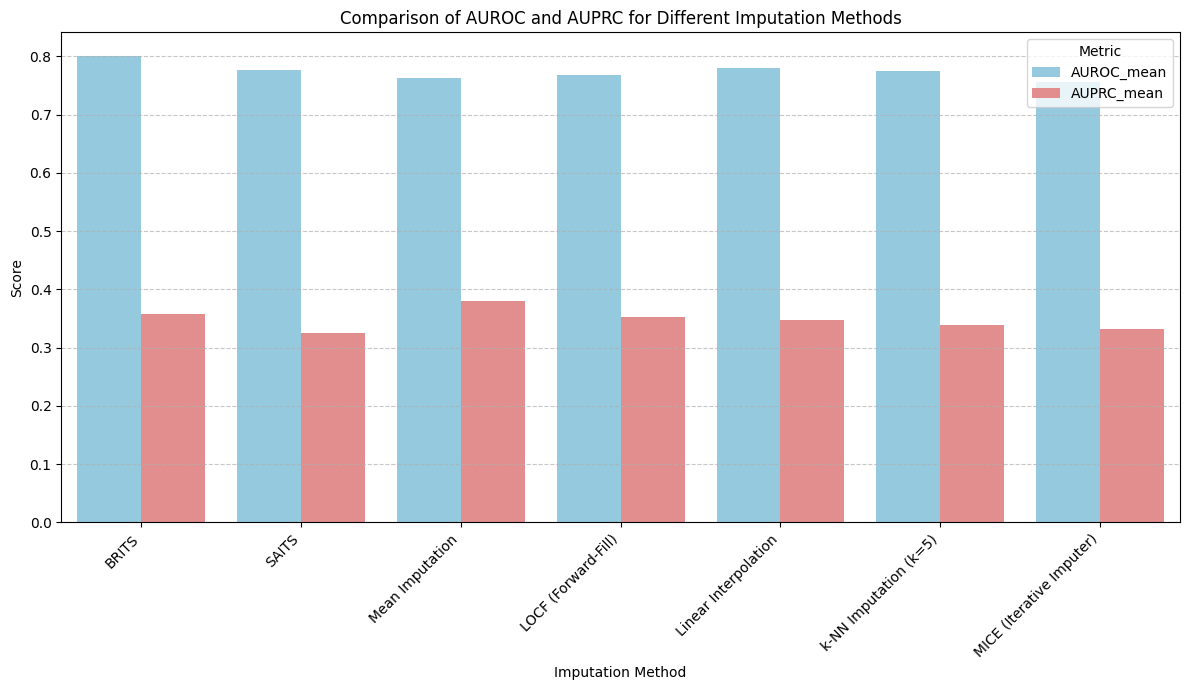

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = task2_summary[['AUROC_mean', 'AUPRC_mean']].reset_index()
plot_data_melted = plot_data.melt(id_vars='index', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='index', y='Score', hue='Metric', data=plot_data_melted, palette={'AUROC_mean': 'skyblue', 'AUPRC_mean': 'lightcoral'})

plt.title('Comparison of AUROC and AUPRC for Different Imputation Methods')
plt.xlabel('Imputation Method')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Correlation Analysis: `macro_norm_mae` vs. `AUROC_mean`

In [ ]:
correlation = final_combined['macro_norm_mae_eval_std'].corr(final_combined['AUROC_mean'])

plt.figure(figsize=(10, 6))
sns.scatterplot(x='macro_norm_mae_eval_std', y='AUROC_mean', data=final_combined, hue=final_combined.index, s=100)
plt.title(f'Correlation between Macro-Normalized MAE (eval-std) and AUROC Mean (Pearson: {correlation:.2f})')
plt.xlabel('Macro-Normalized MAE (eval-std)')
plt.ylabel('AUROC Mean')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Imputation Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(f"Pearson correlation coefficient between Macro-Normalized MAE (eval-std) and AUROC Mean: {correlation:.4f}")